# Safe-to-Play: Athlete Injury Risk Prediction

**Group:** TXC-AS  
**Course:** Machine Learning 2026  
**Dataset:** High Accuracy Sport Injury Dataset (600 athletes)

**Students:**
- 70033 Leticia Brendle
- 
-
-
-
-

---

> **Business Context:**  
> As the Performance Analytics department of a professional football club, our goal is to build a binary classification model: the *Safe-to-Play* classifier. It predicts injury risk based on physiological markers and training workload to support coaching staff in making data-driven decisions about player readiness.

## Table of Contents

1. [Setup & Data Loading](#1.-Setup-&-Data-Loading)
   - [1.1 Data Loading](#1.1-Data-Loading)
   - [1.2 First Look](#1.2-First-Look)
2. [Exploratory Data Analysis](#2.-Exploratory-Data-Analysis)
   - [2.2 Feature Groups](#2.2-Feature-Groups)
   - [2.3 Cross-Group Interactions](#2.3-Cross-Group-Interactions)
   - [2.4 Class Separability: t-SNE Visualisation](#2.4-Class-Separability:-t-SNE-Visualisation)
   - [2.5 EDA Summary: Feature Classification](#2.5-EDA-Summary:-Feature-Classification)
3. [Feature Engineering & Preprocessing](#3.-Feature-Engineering-&-Preprocessing)
   - [3.1 Drop Excluded Features](#3.1-Drop-Excluded-Features)
   - [3.2 Feature Engineering](#3.2-Feature-Engineering)
   - [3.3 Train / Test Split](#3.3-Train-/-Test-Split)
   - [3.4 Scaling](#3.4-Scaling)
4. [Model Training](#4.-Model-Training)
   - [4.1 Logistic Regression with RFE](#4.1-Logistic-Regression-with-RFE)
   - [4.2 Random Forest](#4.2-Random-Forest)
   - [4.3 XGBoost](#4.3-XGBoost)
5. [Model Comparison](#5.-Model-Comparison)
6. [Model Explainability (SHAP)](#6.-Model-Explainability-(SHAP))
7. [Business Recommendations](#7.-Business-Recommendations)

# 1. Setup & Data Loading

In [151]:
# Imports
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
import xgboost as xgb
import shap

# Global plot settings
mpl.rc('axes',  labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
sns.set_style('whitegrid')

RANDOM_STATE = 42  # fixed seed for reproducibility across all models and splits

# Feature-group colour palette (consistent throughout the notebook)
COLOR_BIO       = '#4C72B0'  # blue, biological markers
COLOR_LOAD      = '#DD8452'  # orange, training load
COLOR_RECOVERY  = '#55A868'  # green, recovery & lifestyle
COLOR_CONDITION = '#8172B2'  # purple, physical condition
COLOR_TARGET    = ['#2196F3', '#E53935']  # blue = no risk, red = at risk

print("Libraries loaded.")

Libraries loaded.


## 1.1 Data Loading

In [152]:
df = pd.read_excel('../data/High_Accuracy_Sport_Injury_Dataset.xlsx')
df.head()

,Age,Gender,Height_cm,Weight_kg,BMI,Training_Frequency,Training_Duration,Warmup_Time,Sleep_Hours,Flexibility_Score,Muscle_Asymmetry,Recovery_Time,Injury_History,Stress_Level,Training_Intensity,Injury_Risk
0,36,0,155.4,56.3,23.34,1,94,20,7.2,63.3,3.7,63,1,8,4.4,0
1,30,0,167.6,45.3,16.12,4,114,5,7.1,64.6,5.1,64,1,7,6.7,0
2,21,1,176.7,60.8,19.48,1,95,11,5.0,68.6,6.1,69,0,6,4.3,1
3,37,0,170.2,60.7,20.97,5,73,6,8.1,69.0,4.6,65,2,3,6.4,1
4,30,0,161.5,45.0,17.25,6,93,8,7.8,45.2,8.5,42,3,8,4.2,1


## 1.2 First Look

In [153]:
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

target_dist = pd.DataFrame({
    'Count': df['Injury_Risk'].value_counts(),
    '%': df['Injury_Risk'].value_counts(normalize=True).mul(100).round(1)
})
print(f"\nTarget distribution:\n{target_dist}")

Shape: (600, 16)

Data types:
Age                     int64
Gender                  int64
Height_cm             float64
Weight_kg             float64
BMI                   float64
Training_Frequency      int64
Training_Duration       int64
Warmup_Time             int64
Sleep_Hours           float64
Flexibility_Score     float64
Muscle_Asymmetry      float64
Recovery_Time           int64
Injury_History          int64
Stress_Level            int64
Training_Intensity    float64
Injury_Risk             int64
dtype: object

Missing values:
Age                   0
Gender                0
Height_cm             0
Weight_kg             0
BMI                   0
Training_Frequency    0
Training_Duration     0
Warmup_Time           0
Sleep_Hours           0
Flexibility_Score     0
Muscle_Asymmetry      0
Recovery_Time         0
Injury_History        0
Stress_Level          0
Training_Intensity    0
Injury_Risk           0
dtype: int64

Target distribution:
             Count     %
Injury_Risk    

**First look summary:**
- All 16 features are numeric (int64 / float64), so no encoding is needed for most variables
- No missing values across all 600 records. The dataset is clean and ready to use
- The target is imbalanced: **68.5% safe (0)** vs **31.5% at risk (1)**. We will account for this during modelling with stratified splits and class weighting

# 2. Exploratory Data Analysis

The EDA is structured to directly inform feature engineering decisions. We start with a full correlation overview, then dive into each feature group, and finish with cross-group interactions and a summary of what we take into Section 3.

## 2.1 Correlation with Target

Which features have the strongest relationship with injury risk?

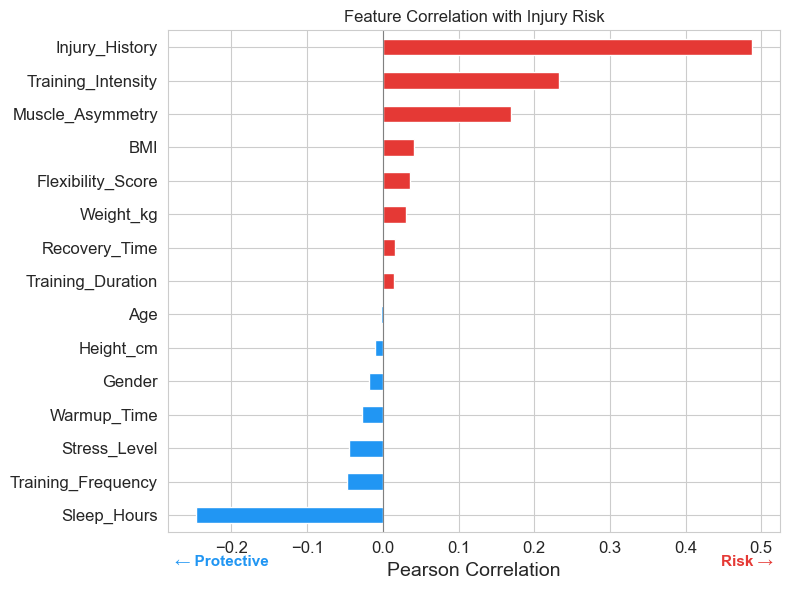

In [154]:
# Correlation of every feature with the target, sorted
corr_target = df.corr()['Injury_Risk'].drop('Injury_Risk').sort_values()

# Color bars by direction: positive = risk (red), negative = protective (blue)
bar_colors = [COLOR_TARGET[1] if c > 0 else COLOR_TARGET[0] for c in corr_target]

fig, ax = plt.subplots(figsize=(8, 6))
corr_target.plot(kind='barh', color=bar_colors, ax=ax)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_title('Feature Correlation with Injury Risk')
ax.set_xlabel('Pearson Correlation')

# Label the two sides of the axis
ax.text(ax.get_xlim()[0] + 0.01, -1.2, '← Protective', color=COLOR_TARGET[0],
        fontsize=11, fontweight='bold', va='top')
ax.text(ax.get_xlim()[1] - 0.01, -1.2, 'Risk →', color=COLOR_TARGET[1],
        fontsize=11, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.show()

**Key takeaways:**
- `Injury_History` is by far the strongest predictor. Prior injuries are the clearest signal of future risk.
- `Sleep_Hours` is the strongest protective factor. More sleep correlates with lower injury risk.
- Training load appears interestingly strong on both sides: `Training_Intensity` is the second strongest risk factor, while `Training_Frequency` is the second strongest protective factor, followed by `Stress_Level`. Unlike history or sleep, **training load is directly controllable by coaching staff.** `Training_Duration` is notably near zero.
- `Muscle_Asymmetry` is the third strongest risk factor. It is a physical/biomechanical signal, indicating that structural imbalances independently contribute to injury.
- `Recovery_Time` and `Warmup_Time` seem to be moderate predictors.
- `Age`, `BMI`, `Height_cm` and `Weight_kg` seem to be weak predictors.

Looking at these results, four natural groups emerge. Fixed physical characteristics like height, weight and age contribute little: professional athletes tend to be homogeneous in build, so these features do not differentiate well. How an athlete trains is a much stronger signal and, uniquely, something coaching staff can directly adjust. How well an athlete recovers day-to-day — sleep, recovery time, stress — reflects behavioural and psychological readiness. Finally, physical condition assessments like muscle asymmetry, flexibility and injury history capture the current medical and biomechanical state of the body, and contain some of the strongest predictors overall.

We will use this grouping to structure the rest of the EDA, examining each group in depth:

| Group | Features |
|---|---|
| Biological markers | Age, Gender, Height_cm, Weight_kg, BMI |
| Training load | Training_Frequency, Training_Duration, Training_Intensity, Warmup_Time |
| Recovery & lifestyle | Sleep_Hours, Recovery_Time, Stress_Level |
| Physical condition | Muscle_Asymmetry, Flexibility_Score, Injury_History |

## 2.2 Feature Groups

We examine each of the four groups for distribution shape, skew and separation between safe and at-risk athletes. This tells us which features need scaling, transformation or can be dropped.

### Biological Markers

In [155]:
# Readable injury class labels for all plots in this section
df['Injury_Class'] = df['Injury_Risk'].map({0: 'Safe', 1: 'At Risk'})
palette_class = {'Safe': COLOR_TARGET[0], 'At Risk': COLOR_TARGET[1]}

/var/folders/1d/khs53zqx6vbf7rqhnxmng9rr0000gn/T/ipykernel_64933/2504417914.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Female (0)', 'Male (1)'])


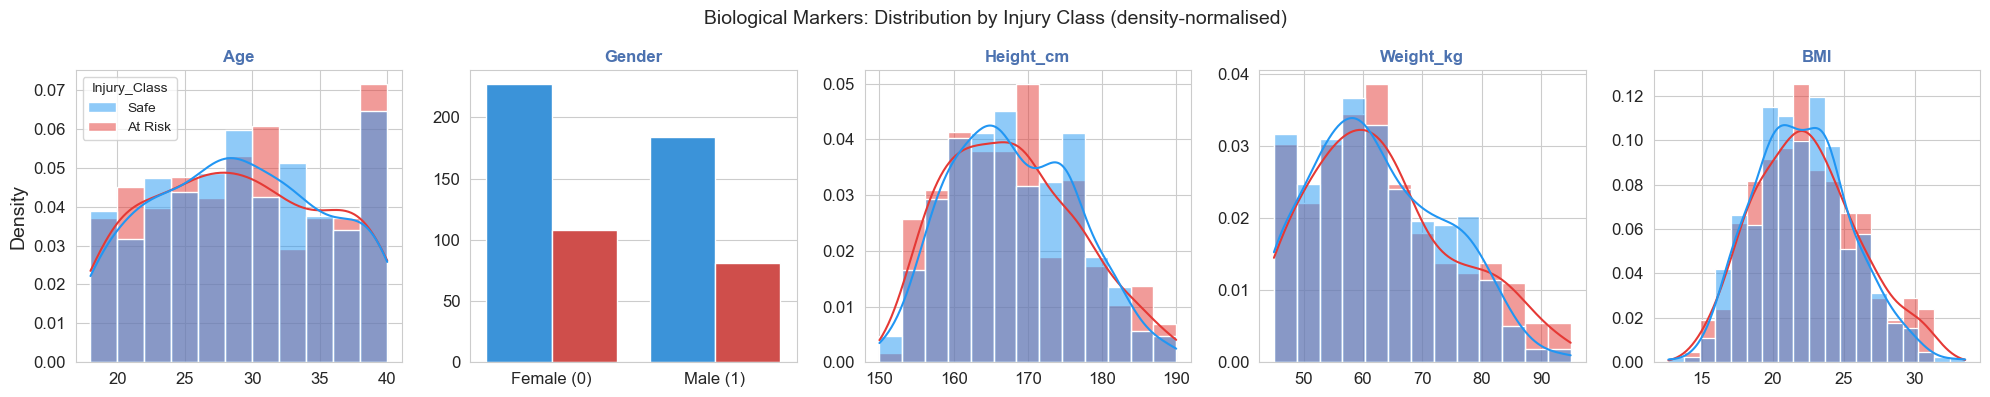

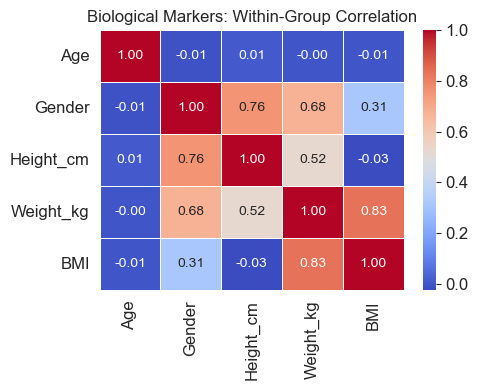

In [156]:
bio_features = ['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, feat in enumerate(bio_features):
    show_legend = (i == 0)
    if df[feat].nunique() <= 2:
        sns.countplot(x=feat, hue='Injury_Class', data=df,
                      palette=palette_class, ax=axes[i],
                      order=sorted(df[feat].unique()))
        axes[i].set_xticklabels(['Female (0)', 'Male (1)'])
        if not show_legend and axes[i].get_legend():
            axes[i].get_legend().remove()
    else:
        # stat='density' normalises each class so shapes are comparable despite class imbalance
        sns.histplot(data=df, x=feat, hue='Injury_Class', palette=palette_class,
                     kde=True, stat='density', common_norm=False,
                     legend=show_legend, ax=axes[i])
    axes[i].set_title(feat, color=COLOR_BIO, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')

fig.suptitle('Biological Markers: Distribution by Injury Class (density-normalised)', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(df[bio_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Biological Markers: Within-Group Correlation')
plt.tight_layout()
plt.show()

**First observation:**
- Age, Height and Weight distributions overlap almost entirely between classes. Visually, there is little separation.
- BMI shows a slight rightward shift for at-risk athletes, but the overlap is still large.
- Gender appears relatively balanced across classes, though hard to judge from counts alone given class imbalance.
- We run two statistical tests to confirm these visual impressions before deciding what to keep.

In [157]:
from scipy.stats import chi2_contingency, mannwhitneyu

safe     = df[df['Injury_Risk'] == 0]
at_risk  = df[df['Injury_Risk'] == 1]

# Chi-squared: Gender vs Injury Risk (categorical)
contingency_table = pd.crosstab(df['Gender'], df['Injury_Risk'])
chi2, p_gender, dof, _ = chi2_contingency(contingency_table)

# Mann-Whitney U: Age vs Injury Risk (continuous, non-parametric)
stat_age, p_age = mannwhitneyu(safe['Age'], at_risk['Age'], alternative='two-sided')

print("Statistical Tests: Biological Markers")
print()
print(f"Gender (Chi-squared):  chi2={chi2:.4f},  p={p_gender:.4f}  ->  {'significant' if p_gender < 0.05 else 'not significant'}")
print(f"Age    (Mann-Whitney): U={stat_age:.0f},     p={p_age:.4f}  ->  {'significant' if p_age    < 0.05 else 'not significant'}")

Statistical Tests: Biological Markers

Gender (Chi-squared):  chi2=0.1222,  p=0.7267  ->  not significant
Age    (Mann-Whitney): U=39026,     p=0.9248  ->  not significant


**Feature classification: Biological Markers**

| Feature | p-value | Classification |
|---|---|---|
| `BMI` | n/a | Test to drop in model phase |
| `Gender` | 0.05+ | Descriptive variable (demographic control) |
| `Age` | 0.05+ | Excluded (near-zero correlation, not significant) |
| `Height_cm` | n/a | Excluded (redundant with BMI) |
| `Weight_kg` | n/a | Excluded (redundant with BMI) |

See 2.4 for the full feature classification across all groups.

### Training Load

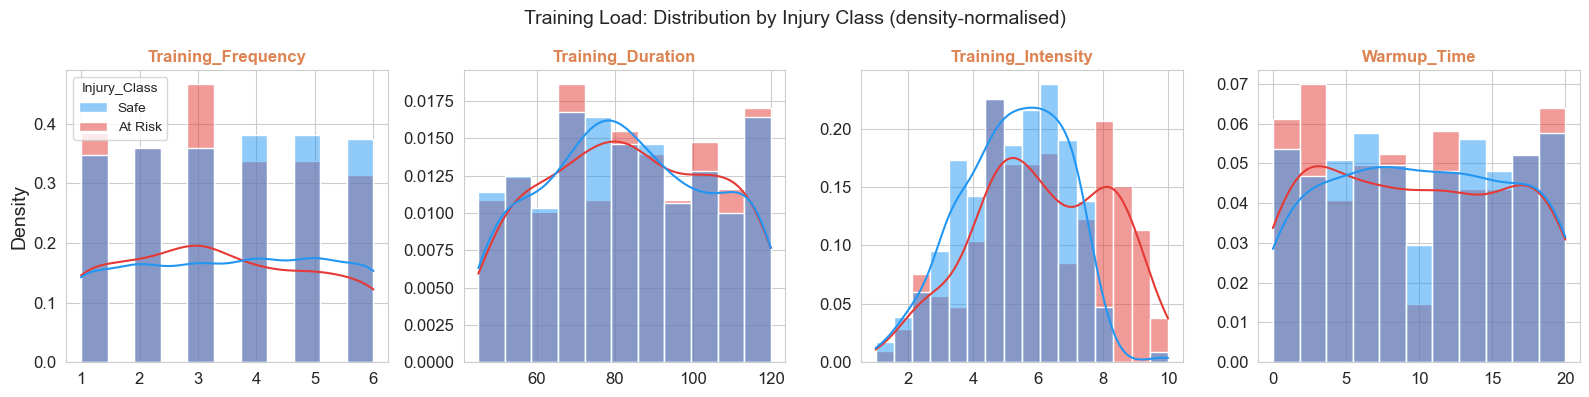

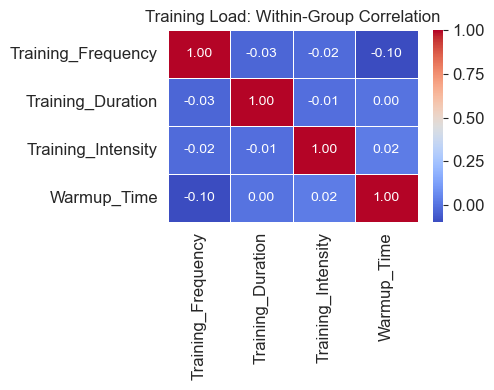

In [158]:
load_features = ['Training_Frequency', 'Training_Duration', 'Training_Intensity', 'Warmup_Time']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(load_features):
    sns.histplot(data=df, x=feat, hue='Injury_Class', palette=palette_class,
                 kde=True, stat='density', common_norm=False,
                 legend=(i == 0), ax=axes[i])
    axes[i].set_title(feat, color=COLOR_LOAD, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')

fig.suptitle('Training Load: Distribution by Injury Class (density-normalised)', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(df[load_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Training Load: Within-Group Correlation')
plt.tight_layout()
plt.show()

**First observation:**
- `Training_Intensity` shows the clearest separation between classes. At-risk athletes tend to train at higher intensities.
- `Training_Frequency` shifts slightly toward lower values for at-risk athletes, suggesting less frequent but harder training is a risk pattern.
- `Training_Duration` and `Warmup_Time` show heavy overlap. Their individual signal looks weak visually.
- No multicollinearity within this group (heatmap near zero). We run Mann-Whitney U tests to confirm which features are statistically significant.

In [159]:
print("Statistical Tests: Training Load (Mann-Whitney U)\n")
for feat in load_features:
    stat, p = mannwhitneyu(safe[feat], at_risk[feat], alternative='two-sided')
    sig = 'significant' if p < 0.05 else 'not significant'
    print(f"  {feat:<25} U={stat:.0f},  p={p:.4f}  ->  {sig}")

Statistical Tests: Training Load (Mann-Whitney U)

  Training_Frequency        U=41121,  p=0.2408  ->  not significant
  Training_Duration         U=38128,  p=0.7185  ->  not significant
  Training_Intensity        U=28776,  p=0.0000  ->  significant
  Warmup_Time               U=40210,  p=0.4870  ->  not significant


**Feature classification: Training Load**

| Feature | p-value | Classification |
|---|---|---|
| `Training_Intensity` | 0.0000 | Clear good feature |
| `Training_Frequency` | 0.2408 | Test to drop in model phase |
| `Training_Duration` | 0.7185 | Test to drop in model phase |
| `Warmup_Time` | 0.4870 | Test to drop in model phase |

See 2.4 for the full feature classification across all groups.

### Recovery & Lifestyle

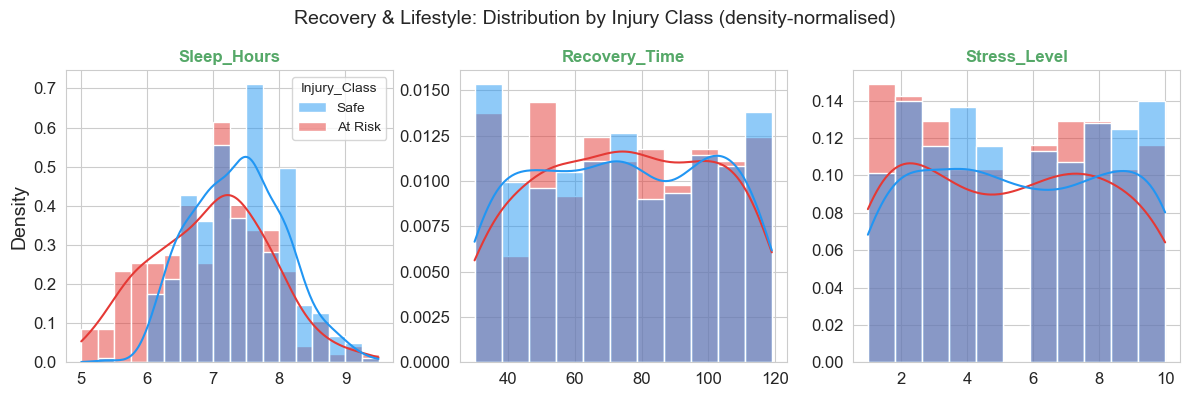

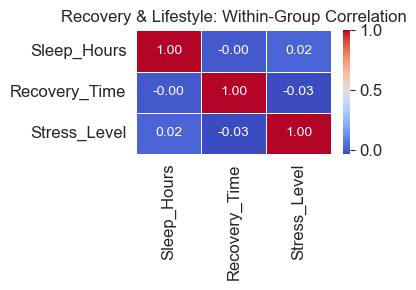

In [160]:
recovery_features = ['Sleep_Hours', 'Recovery_Time', 'Stress_Level']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, feat in enumerate(recovery_features):
    sns.histplot(data=df, x=feat, hue='Injury_Class', palette=palette_class,
                 kde=True, stat='density', common_norm=False,
                 legend=(i == 0), ax=axes[i])
    axes[i].set_title(feat, color=COLOR_RECOVERY, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')

fig.suptitle('Recovery & Lifestyle: Distribution by Injury Class (density-normalised)', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(df[recovery_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Recovery & Lifestyle: Within-Group Correlation')
plt.tight_layout()
plt.show()

**First observation:**
- `Sleep_Hours` shows a clear leftward shift for at-risk athletes. Less sleep is visually the strongest signal in this group.
- `Stress_Level` shows a slight separation but in the protective direction, which is counterintuitive.
- `Recovery_Time` shows heavy overlap between classes. Its signal looks weak visually.
- We run Mann-Whitney U tests to confirm significance before deciding what to keep.

In [161]:
print("Statistical Tests: Recovery & Lifestyle (Mann-Whitney U)\n")
for feat in recovery_features:
    stat, p = mannwhitneyu(safe[feat], at_risk[feat], alternative='two-sided')
    sig = 'significant' if p < 0.05 else 'not significant'
    print(f"  {feat:<25} U={stat:.0f},  p={p:.4f}  ->  {sig}")

Statistical Tests: Recovery & Lifestyle (Mann-Whitney U)

  Sleep_Hours               U=49461,  p=0.0000  ->  significant
  Recovery_Time             U=38060,  p=0.6929  ->  not significant
  Stress_Level              U=41032,  p=0.2640  ->  not significant


**Feature classification: Recovery & Lifestyle**

| Feature | p-value | Classification |
|---|---|---|
| `Sleep_Hours` | 0.0000 | Clear good feature |
| `Stress_Level` | 0.2640 | Test to drop in model phase |
| `Recovery_Time` | 0.6929 | Test to drop in model phase |

See 2.4 for the full feature classification across all groups.

### Physical Condition

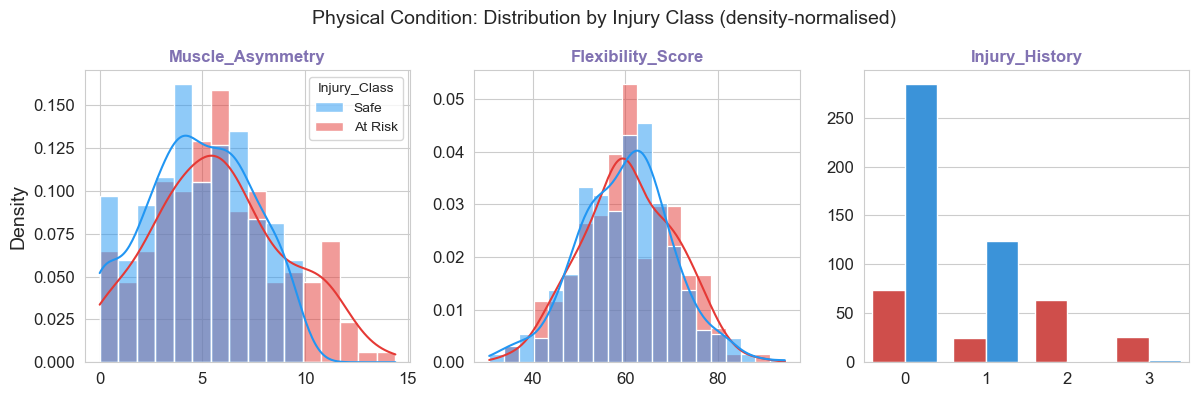

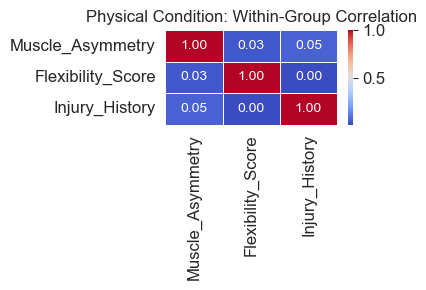

In [162]:
condition_features = ['Muscle_Asymmetry', 'Flexibility_Score', 'Injury_History']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, feat in enumerate(condition_features):
    show_legend = (i == 0)
    if df[feat].nunique() <= 5:  # treat as categorical if few unique values
        sns.countplot(x=feat, hue='Injury_Class', data=df,
                      palette=palette_class, ax=axes[i],
                      order=sorted(df[feat].unique()))
        if not show_legend and axes[i].get_legend():
            axes[i].get_legend().remove()
    else:
        sns.histplot(data=df, x=feat, hue='Injury_Class', palette=palette_class,
                     kde=True, stat='density', common_norm=False,
                     legend=show_legend, ax=axes[i])
    axes[i].set_title(feat, color=COLOR_CONDITION, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '')

fig.suptitle('Physical Condition: Distribution by Injury Class (density-normalised)', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(df[condition_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Physical Condition: Within-Group Correlation')
plt.tight_layout()
plt.show()

**First observation:**
- `Injury_History` shows the starkest separation of any feature in the entire dataset. Athletes with prior injuries are heavily concentrated in the at-risk class.
- `Muscle_Asymmetry` shows a rightward shift for at-risk athletes. Structural imbalances appear to be a meaningful signal.
- `Flexibility_Score` shows considerable overlap. Its value as a standalone predictor looks limited visually.
- We run Mann-Whitney U tests to confirm which features are statistically significant.

In [163]:
print("Statistical Tests: Physical Condition (Mann-Whitney U)\n")
for feat in condition_features:
    stat, p = mannwhitneyu(safe[feat], at_risk[feat], alternative='two-sided')
    sig = 'significant' if p < 0.05 else 'not significant'
    print(f"  {feat:<25} U={stat:.0f},  p={p:.4f}  ->  {sig}")

Statistical Tests: Physical Condition (Mann-Whitney U)

  Muscle_Asymmetry          U=32240,  p=0.0008  ->  significant
  Flexibility_Score         U=37330,  p=0.4441  ->  not significant
  Injury_History            U=21717,  p=0.0000  ->  significant


**Feature classification: Physical Condition**

| Feature | p-value | Classification |
|---|---|---|
| `Injury_History` | 0.0000 | Clear good feature |
| `Muscle_Asymmetry` | 0.0008 | Clear good feature |
| `Flexibility_Score` | 0.4441 | Test to drop in model phase |

See 2.4 for the full feature classification across all groups.

## 2.3 Cross-Group Interactions

A full correlation matrix across all features. This reveals multicollinearity between groups and hints at interaction features worth engineering (e.g. high training intensity combined with low sleep).

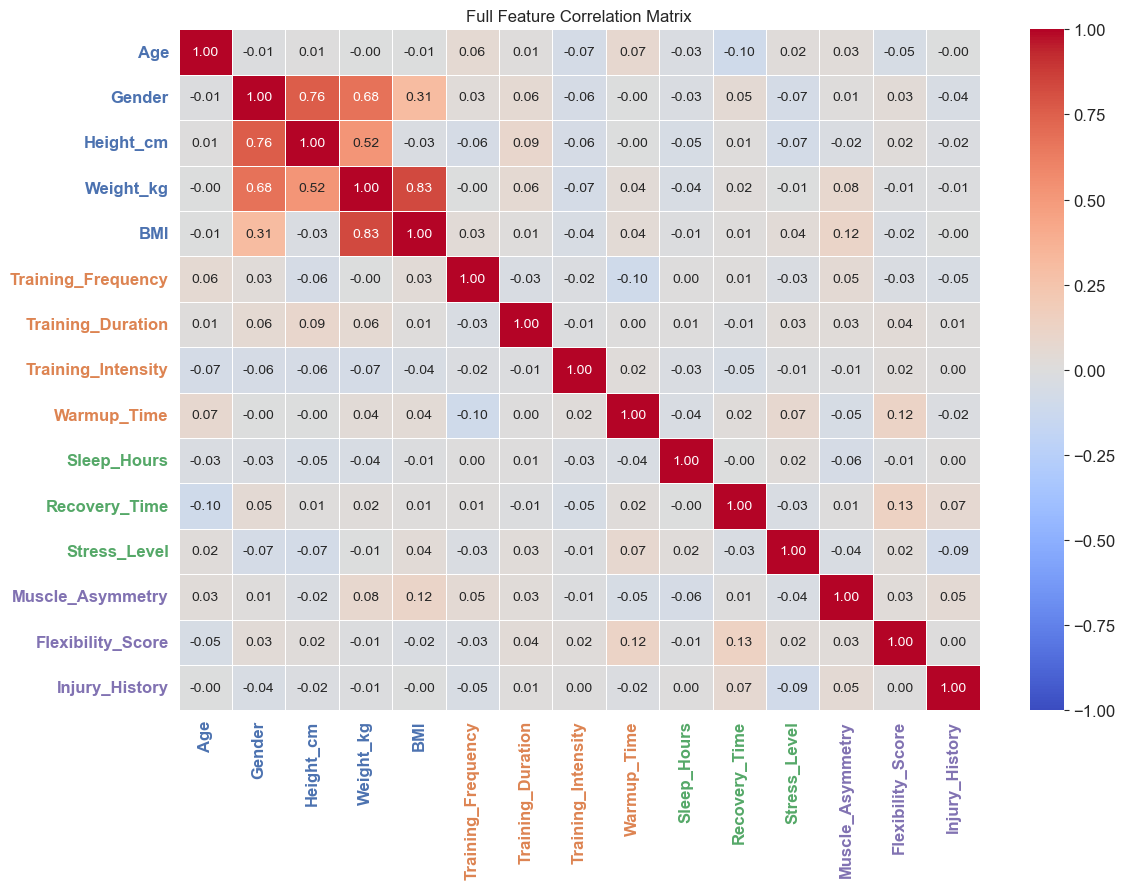

In [164]:
# Full correlation matrix, ordered by feature group for readability
all_features = bio_features + load_features + recovery_features + condition_features
corr_full = df[all_features].corr()

# Map each feature to its group color
feature_colors = (
    {f: COLOR_BIO       for f in bio_features} |
    {f: COLOR_LOAD      for f in load_features} |
    {f: COLOR_RECOVERY  for f in recovery_features} |
    {f: COLOR_CONDITION for f in condition_features}
)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Full Feature Correlation Matrix')

# Color axis labels by feature group
for tick in ax.get_xticklabels():
    tick.set_color(feature_colors.get(tick.get_text(), 'black'))
    tick.set_fontweight('bold')
for tick in ax.get_yticklabels():
    tick.set_color(feature_colors.get(tick.get_text(), 'black'))
    tick.set_fontweight('bold')

plt.tight_layout()
plt.show()

**Cross-group observations:**

**Multicollinearity within biological markers:** `Height_cm`, `Weight_kg` and `BMI` are highly correlated (Weight-BMI: r=0.83, Gender-Height: r=0.76, Gender-Weight: r=0.68). `Gender` is essentially a size proxy in this dataset: males tend to be taller and heavier, which explains why gender itself adds no independent injury signal. We retain only `BMI` and drop the rest.

**The four strongest predictors are independent from each other:** `Injury_History`, `Training_Intensity`, `Sleep_Hours` and `Muscle_Asymmetry` show near-zero correlations with one another. This is important: they capture genuinely different aspects of athlete condition with no redundancy. For a Logistic Regression model, low multicollinearity among key features means coefficients will be stable and interpretable.

**Stress and sleep are unrelated:** `Stress_Level` and `Sleep_Hours` show near-zero correlation (-0.09). One might expect high stress to reduce sleep in professional athletes, but this dataset suggests the two are driven by different factors. It also confirms they would not be redundant if both were kept.

**Two combinations worth investigating:** `Training_Intensity` is independent from both `Training_Duration` (r≈-0.01) and `Sleep_Hours` (r≈-0.03), meaning athletes vary freely across all combinations of these dimensions. From a coaching perspective this raises two natural questions: does the total cost of a session (intensity × duration) matter beyond either factor alone, and does training hard while sleeping poorly create a risk that neither feature captures individually? We explore both as engineered features in Section 3.2.

## 2.4 Class Separability: t-SNE Visualisation

Before building any model, it is worth asking: do the features together actually separate safe from at-risk athletes? t-SNE compresses all 12 features into 2 dimensions while trying to keep similar athletes close together. The result is a scatter plot where each dot is one athlete. If the two classes form distinct clusters, a classifier will have a good chance of learning the boundary.

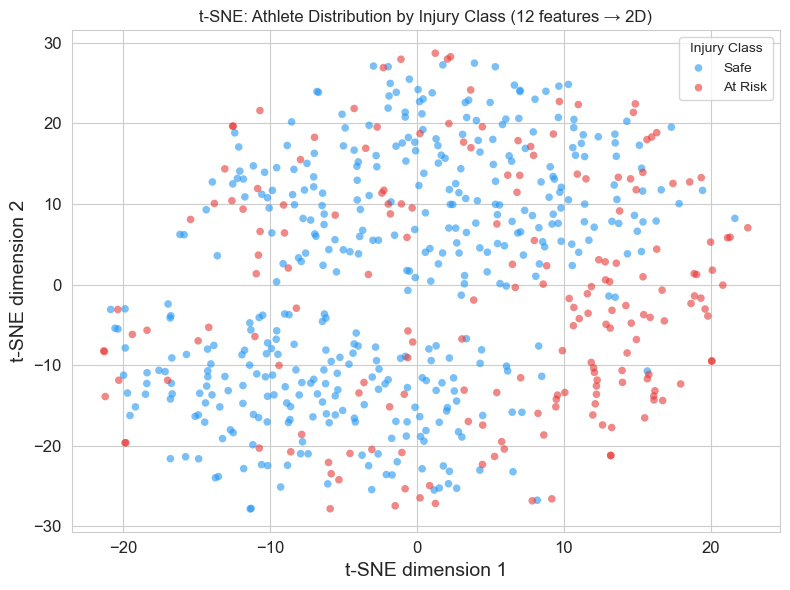

In [165]:
from sklearn.manifold import TSNE

# Use the same 12 features that enter the models (excluding Age, Height_cm, Weight_kg)
tsne_features = [c for c in df.columns if c not in
                 ['Age', 'Height_cm', 'Weight_kg', 'Injury_Risk', 'Injury_Class']]

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(StandardScaler().fit_transform(df[tsne_features]))

tsne_df = pd.DataFrame({'x': X_tsne[:, 0], 'y': X_tsne[:, 1],
                        'Injury_Class': df['Injury_Class']})

fig, ax = plt.subplots(figsize=(8, 6))
for label, color in [('Safe', COLOR_TARGET[0]), ('At Risk', COLOR_TARGET[1])]:
    mask = tsne_df['Injury_Class'] == label
    ax.scatter(tsne_df.loc[mask, 'x'], tsne_df.loc[mask, 'y'],
               c=color, label=label, alpha=0.6, s=30, edgecolors='none')

ax.set_title('t-SNE: Athlete Distribution by Injury Class (12 features → 2D)')
ax.set_xlabel('t-SNE dimension 1')
ax.set_ylabel('t-SNE dimension 2')
ax.legend(title='Injury Class')
plt.tight_layout()
plt.show()

The t-SNE plot shows that safe (blue) and at-risk (red) athletes are broadly intermingled across the 2D space. There are no compact, well-separated clusters — red dots appear throughout the plot alongside blue ones. This tells us the 12 features do not collectively produce a clean, linearly separable boundary in the data.

That said, the distribution is not completely random. Looking at the right side and lower regions of the plot, there is a slight tendency for red dots to be more concentrated, while the central and upper-left regions are more heavily blue. This partial, soft separation suggests the features carry *some* signal, but the injury risk boundary in this dataset is fuzzy and complex.

The practical implication for modelling: accuracy ceilings will be real. No model will achieve near-perfect classification here. We can expect non-linear models (Random Forest, XGBoost) to outperform Logistic Regression by capturing subtle local patterns that the t-SNE structure hints at, but the overlap means false negatives and false positives will remain in any model's predictions.

## 2.5 EDA Summary: Feature Classification

We organised the 15 features into four groups based on what they measure: biological markers, training load, recovery & lifestyle, and physical condition. Across all groups, the EDA reveals a clear pattern. Physical condition is the strongest signal, with `Injury_History` and `Muscle_Asymmetry` standing out. Training load is uniquely two-sided: high intensity increases risk, while frequency is protective. Sleep is the strongest lifestyle factor. Biological markers contribute little, likely because athletes in a professional club are physically homogeneous.

The cross-group correlation matrix in 2.3 was largely clean, with no problematic dependencies between groups. The main finding was a set of independent relationships within the training load and recovery features that hint at potentially informative combinations. We act on this in Section 3.2.

The t-SNE visualisation in 2.4 adds an important caveat: even combining all 12 features, the two classes remain broadly intermingled. There is no clean separable boundary. This means we should expect models to struggle with borderline cases and that recall on the at-risk class, the most costly error, will be the key metric to watch in Section 4.

All 15 features are classified below, ordered from most to least predictive, based on correlation with the target (2.1) and statistical significance from the group-level tests.

| Feature | r with target | Significant? | Classification |
|---|---|---|---|
| `Injury_History` | 0.49 | Yes | **Clear good feature** |
| `Training_Intensity` | 0.23 | Yes | **Clear good feature** |
| `Sleep_Hours` | -0.25 | Yes | **Clear good feature** |
| `Muscle_Asymmetry` | 0.17 | Yes | **Clear good feature** |
| `Training_Frequency` | -0.13 | No | Test to drop in model phase |
| `Stress_Level` | -0.12 | No | Test to drop in model phase |
| `BMI` | 0.07 | No | Test to drop in model phase |
| `Flexibility_Score` | 0.07 | No | Test to drop in model phase |
| `Warmup_Time` | -0.08 | No | Test to drop in model phase |
| `Training_Duration` | 0.05 | No | Test to drop in model phase |
| `Recovery_Time` | 0.04 | No | Test to drop in model phase |
| `Gender` | -0.05 | No | Descriptive variable (kept as demographic control) |
| `Age` | 0.00 | No | Excluded |
| `Height_cm` | 0.00 | No | Excluded (redundant with BMI) |
| `Weight_kg` | 0.00 | No | Excluded (redundant with BMI) |

"Test to drop in model phase" features will be included in Section 3 and evaluated during model comparison. Features that do not contribute to performance will be removed at that stage.

**Steps in Section 3:**
- Apply `StandardScaler` to all continuous features (different scales and units)
- Split: 70% train / 30% test, stratified on target, `random_state=42`. Model selection via 5-fold `StratifiedKFold` cross-validation on the train set. Test set held out for final evaluation only.

# 3. Feature Engineering & Preprocessing

The EDA identified which features to keep and which to exclude. Before modelling we take two additional steps: create two domain-motivated composite features that capture athlete stress and workload in ways the raw features cannot, then prepare the data for training by splitting and scaling.

## 3.1 Drop Excluded Features

We remove `Age`, `Height_cm` and `Weight_kg` as established in the EDA. `Injury_Class` (the readable label column created for plots) is also removed as it is not a model input.

In [166]:
cols_to_drop = ['Age', 'Height_cm', 'Weight_kg', 'Injury_Class']
df_model = df.drop(columns=cols_to_drop)

X = df_model.drop(columns=['Injury_Risk'])
y = df_model['Injury_Risk']

print(f"Features going into modelling ({X.shape[1]}): {list(X.columns)}")
print(f"Target: Injury_Risk, shape: {y.shape}")

Features going into modelling (12): ['Gender', 'BMI', 'Training_Frequency', 'Training_Duration', 'Warmup_Time', 'Sleep_Hours', 'Flexibility_Score', 'Muscle_Asymmetry', 'Recovery_Time', 'Injury_History', 'Stress_Level', 'Training_Intensity']
Target: Injury_Risk, shape: (600,)


## 3.2 Feature Engineering

Section 2.3 flagged a cross-group pattern worth investigating: `Training_Intensity` and `Sleep_Hours` are independently strong predictors, pointing in opposite directions, and coaching intuition suggests their *combination* matters more than either alone. An athlete pushing hard while sleeping poorly is in a qualitatively different situation from one doing the same training load with adequate rest.

To test this, we check whether a ratio of the two features carries more signal than the individual features:

- `Training_Intensity` vs target: r=+0.23 (risk factor)
- `Sleep_Hours` vs target: r=-0.25 (protective factor)
- Correlation between them: r≈-0.03 (essentially independent)

The near-zero mutual correlation is what makes the ratio statistically valid: because the two features vary independently across athletes, the ratio `Training_Intensity / Sleep_Hours` spans a genuinely wide range of combinations, from athletes who train lightly and sleep well to those who train hard and sleep poorly. If the features were correlated, the ratio would be redundant with either parent. Because they are not, the ratio creates a new dimension of information.

The same logic applies to `Training_Intensity × Training_Duration`. Intensity and duration are also uncorrelated (r≈-0.01), so their product captures the total physiological cost of a session, a concept known as session-RPE in sports science, rather than simply restating either dimension alone.

We create both features below and validate with a correlation check before proceeding to modelling.

In [167]:
df_model = df_model.copy()

# Load-Recovery Ratio: how hard an athlete trains relative to how well they recover
df_model['Load_Recovery_Ratio'] = df_model['Training_Intensity'] / df_model['Sleep_Hours']

# Total Training Load: combined physiological cost of a session (intensity × duration)
df_model['Training_Load'] = df_model['Training_Intensity'] * df_model['Training_Duration']

X = df_model.drop(columns=['Injury_Risk'])
y = df_model['Injury_Risk']

print(f"Features after engineering ({X.shape[1]}): {list(X.columns)}")

# Quick sanity check: correlation of new features with target
new_feats = ['Load_Recovery_Ratio', 'Training_Load']
corr_new = df_model[new_feats + ['Injury_Risk']].corr()['Injury_Risk'].drop('Injury_Risk')
print(f"\nCorrelation with Injury_Risk:")
print(corr_new.round(4))

Features after engineering (14): ['Gender', 'BMI', 'Training_Frequency', 'Training_Duration', 'Warmup_Time', 'Sleep_Hours', 'Flexibility_Score', 'Muscle_Asymmetry', 'Recovery_Time', 'Injury_History', 'Stress_Level', 'Training_Intensity', 'Load_Recovery_Ratio', 'Training_Load']

Correlation with Injury_Risk:
Load_Recovery_Ratio    0.3033
Training_Load          0.1755
Name: Injury_Risk, dtype: float64


The correlations confirm the engineering decisions were well-founded. `Load_Recovery_Ratio` (r=0.30) becomes the third strongest predictor in the entire feature set, ranking above both `Training_Intensity` (r=0.23) and `Muscle_Asymmetry` (r=0.17). This validates the hypothesis from Section 2.3: combining two uncorrelated but individually predictive features into a ratio captures signal that neither parent feature contains alone. `Training_Load` (r=0.18) also adds meaningful signal beyond what `Training_Intensity` or `Training_Duration` provide individually.

Both engineered features will be included in the RFE ranking for Logistic Regression and passed alongside all 14 features to Random Forest and XGBoost.

## 3.3 Train / Test Split

We split into 70% train and 30% test. The train set is used with 5-fold cross-validation for model selection. The test set is held out completely and only used for final evaluation.

In [168]:
from sklearn.model_selection import StratifiedKFold

# 70% train, 30% test, stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

# StratifiedKFold for cross-validation on the training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print()
print("Class balance per split:")
for name, y_split in [("Train", y_train), ("Test", y_test)]:
    pct = y_split.value_counts(normalize=True).mul(100).round(1)
    print(f"  {name:<8}: Safe {pct[0]}%  |  At Risk {pct[1]}%")
print()
print(f"Cross-validation: {cv.n_splits}-fold StratifiedKFold on train set")

Train : 420 samples (70%)
Test  : 180 samples (30%)

Class balance per split:
  Train   : Safe 68.6%  |  At Risk 31.4%
  Test    : Safe 68.3%  |  At Risk 31.7%

Cross-validation: 5-fold StratifiedKFold on train set


## 3.4 Scaling

`StandardScaler` is fitted on the training set only and applied to the test set. This prevents data leakage: the test set must not influence the scaling parameters. The two engineered features are scaled alongside the originals.

In [169]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled  = scaler.transform(X_test)        # apply same scale to test

# Wrap back into DataFrames to keep feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("Scaling complete.")
print(f"Train mean (should be ~0): {X_train_scaled.mean().round(2).values}")
print(f"Train std  (should be ~1): {X_train_scaled.std().round(2).values}")

Scaling complete.
Train mean (should be ~0): [-0. -0.  0. -0. -0.  0.  0. -0.  0. -0. -0. -0.  0. -0.]
Train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Section 3 summary:**
- 3 features excluded: `Age`, `Height_cm`, `Weight_kg`
- 2 composite features created: `Load_Recovery_Ratio`, `Training_Load`
- 14 features entering the models: 4 clear good features + 2 engineered + 8 to evaluate
- Split: 420 train (70%) / 180 test (30%), class balance preserved in both
- Model selection via 5-fold StratifiedKFold cross-validation on the train set
- Scaler fitted on train only to prevent data leakage

# 4. Model Training

## 4.0 Model Selection Rationale

The task is **binary classification**: predict whether an athlete is at risk of injury (1) or safe to play (0). This narrows the universe of suitable algorithms to those designed for probabilistic binary output, where we need not just a prediction but a confidence score that coaching staff can act on.

Three properties of the data, established in Sections 2 and 3, shape our model choices:

**The boundary is likely non-linear.** The t-SNE visualisation in Section 2.4 showed that safe and at-risk athletes are broadly intermingled in feature space, with no clean separable boundary. A model that can only draw a straight line through the data will systematically struggle with the overlap region. This tells us that a linear classifier will serve as a useful baseline, but is unlikely to be the best performer.

**The data is imbalanced.** At 68.5% safe vs 31.5% at-risk, a naive model can achieve 68.5% accuracy by predicting "safe" every time. All three models must therefore be configured to account for class imbalance, and accuracy alone is not a meaningful evaluation metric. Recall on the at-risk class is what matters operationally.

**The features include non-linear interactions.** Section 3.2 showed that engineered ratios and products of uncorrelated features carry more predictive signal than the raw features individually, suggesting the relationship between inputs and injury risk is not purely additive.

Given these properties, we select three models that together span a range of complexity and interpretability:

| Model | Why appropriate |
|---|---|
| **Logistic Regression** | Linear baseline. Interpretable coefficients. Establishes a performance floor and tests whether the problem has a meaningful linear component at all. Expected to underperform on the intermingled boundary identified by t-SNE. |
| **Random Forest** | Non-linear ensemble of decision trees. Handles interactions automatically. Robust to irrelevant features. Provides built-in feature importance. A natural next step when the linear model leaves unexplained variance. |
| **XGBoost** | Gradient boosting. Sequentially corrects residual errors, making it particularly strong when patterns are complex and partially overlapping. Typically the best performer on structured tabular data with class imbalance. |

For each model we follow the same protocol:
1. Train on the 420-sample training set
2. Evaluate via 5-fold stratified cross-validation on the training set
3. Predict on the 180-sample held-out test set
4. Report: accuracy, precision, recall, F1, ROC-AUC

All metrics are reported on the test set so comparisons are fair. Cross-validation scores on the training set confirm each model generalises rather than overfits.

In [170]:
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFECV

# Reusable evaluation helper: returns all 5 metrics for any fitted classifier
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'Accuracy':  round(accuracy_score(y_test,  y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test,    y_pred), 4),
        'F1':        round(f1_score(y_test,        y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test,  y_prob), 4),
    }

## 4.1 Logistic Regression with RFE

**Logistic Regression** is the natural linear baseline for binary classification. It models the log-odds of injury risk as a linear combination of the input features and outputs a probability between 0 and 1. It is interpretable, fast to train, and gives us a clear benchmark to assess whether more complex models add value.

**Why RFE?** We enter Section 4 with 14 features, several of which were flagged in the EDA as weak predictors. Recursive Feature Elimination (RFE) ranks all features by their importance to the model, removing the least useful ones step by step. By setting `n_features_to_select=1` we obtain a full ranking from strongest (rank 1) to weakest (rank 14). This lets us inspect the ranking and choose the cutoff based on where the signal drops off, rather than guessing upfront.

We use `class_weight='balanced'` to account for the 68.5/31.5 class imbalance.

RFE Feature Ranking (rank 1 = most important):

            Feature  Rank
     Injury_History     1
Load_Recovery_Ratio     2
      Training_Load     3
  Training_Duration     4
   Muscle_Asymmetry     5
 Training_Intensity     6
        Sleep_Hours     7
 Training_Frequency     8
      Recovery_Time     9
  Flexibility_Score    10
                BMI    11
        Warmup_Time    12
             Gender    13
       Stress_Level    14


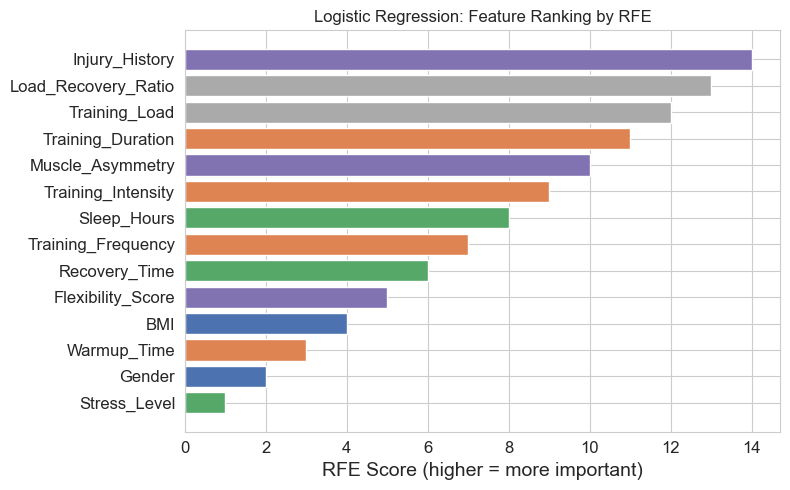

In [171]:
from sklearn.feature_selection import RFE

# RFE with n_features_to_select=1 gives a unique rank to every feature
lr_rfe = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
rfe = RFE(estimator=lr_rfe, n_features_to_select=1)
rfe.fit(X_train_scaled, y_train)

# Build a summary table: rank 1 = most important, 12 = least important
rfe_ranking = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Rank':    rfe.ranking_
}).sort_values('Rank')

print("RFE Feature Ranking (rank 1 = most important):\n")
print(rfe_ranking.to_string(index=False))

# Color bars by feature group
group_colors = (
    {f: COLOR_BIO       for f in bio_features} |
    {f: COLOR_LOAD      for f in load_features} |
    {f: COLOR_RECOVERY  for f in recovery_features} |
    {f: COLOR_CONDITION for f in condition_features}
)
bar_colors = [group_colors.get(f, '#AAAAAA') for f in rfe_ranking['Feature']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(rfe_ranking['Feature'], rfe_ranking['Rank'].max() - rfe_ranking['Rank'] + 1,
        color=bar_colors)
ax.set_xlabel('RFE Score (higher = more important)')
ax.set_title('Logistic Regression: Feature Ranking by RFE')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

The RFE ranking with 14 features directly validates the feature engineering. `Load_Recovery_Ratio` ranks 2nd and `Training_Load` ranks 3rd, both ahead of their parent features `Training_Intensity` (6th), `Sleep_Hours` (7th) and `Training_Duration` (4th). The engineered composites carry more linear signal for injury risk than the raw features they were built from.

The group colours show the same bottom tier: biological markers (blue) and weak load/recovery features cluster at the bottom. `Stress_Level`, `Gender`, `Warmup_Time`, `BMI`, `Flexibility_Score` and `Recovery_Time` all rank in the bottom six.

RFE is a linear pre-selection step suited to Logistic Regression. Random Forest and XGBoost have their own internal mechanisms to downweight weak features, so they will receive all 14 features in Sections 4.2 and 4.3.

Before fixing `N_FEATURES`, we test all cutoffs from 6 to 14 using the same 5-fold CV. This makes the final choice data-driven rather than arbitrary.

In [172]:
# Simulate different feature cutoffs to find the optimal N_FEATURES for LR
print("N_FEATURES | CV ROC-AUC (mean ± std) | Features dropped")
print("-" * 70)
for n in range(6, 15):
    feats = rfe_ranking[rfe_ranking['Rank'] <= n]['Feature'].tolist()
    lr_sim = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
    scores = cross_val_score(lr_sim, X_train_scaled[feats], y_train, cv=cv, scoring='roc_auc')
    dropped = rfe_ranking[rfe_ranking['Rank'] > n]['Feature'].tolist()
    print(f"  {n:<10} | {scores.mean():.4f} ± {scores.std():.4f}          | drop: {dropped}")

N_FEATURES | CV ROC-AUC (mean ± std) | Features dropped
----------------------------------------------------------------------
  6          | 0.8930 ± 0.0302          | drop: ['Sleep_Hours', 'Training_Frequency', 'Recovery_Time', 'Flexibility_Score', 'BMI', 'Warmup_Time', 'Gender', 'Stress_Level']
  7          | 0.8925 ± 0.0303          | drop: ['Training_Frequency', 'Recovery_Time', 'Flexibility_Score', 'BMI', 'Warmup_Time', 'Gender', 'Stress_Level']
  8          | 0.8926 ± 0.0309          | drop: ['Recovery_Time', 'Flexibility_Score', 'BMI', 'Warmup_Time', 'Gender', 'Stress_Level']
  9          | 0.8933 ± 0.0302          | drop: ['Flexibility_Score', 'BMI', 'Warmup_Time', 'Gender', 'Stress_Level']
  10         | 0.8917 ± 0.0298          | drop: ['BMI', 'Warmup_Time', 'Gender', 'Stress_Level']
  11         | 0.8909 ± 0.0298          | drop: ['Warmup_Time', 'Gender', 'Stress_Level']
  12         | 0.8906 ± 0.0295          | drop: ['Gender', 'Stress_Level']
  13         | 0.8891 ± 0.032

Performance is remarkably flat across all cutoffs: AUC ranges only from 0.886 to 0.893 across N=6 to N=14, confirming the model is robust to the exact cutoff chosen. The marginal peak is at N=9 (0.8933), but N=8 (0.8926) is essentially identical. We keep `N_FEATURES = 8`: it sits at the natural tier break identified in the RFE ranking, drops the six weakest features with near-zero signal, and avoids adding noise from borderline features that contribute almost nothing.

In [173]:
N_FEATURES = 8  # drop the 6 weakest by RFE: Recovery_Time, Flexibility_Score, BMI, Warmup_Time, Gender, Stress_Level

# Select top 8 features for Logistic Regression (RFE is a linear pre-selection step)
selected_features = rfe_ranking[rfe_ranking['Rank'] <= N_FEATURES]['Feature'].tolist()
print(f"LR input ({N_FEATURES} features): {selected_features}")

X_train_lr = X_train_scaled[selected_features]
X_test_lr  = X_test_scaled[selected_features]

# Train final Logistic Regression
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_lr, y_train)

# 5-fold cross-validation on train set
cv_scores = cross_val_score(log_reg, X_train_lr, y_train, cv=cv, scoring='roc_auc')
print(f"\nCV ROC-AUC (5-fold): {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")
print(f"Per fold:            {cv_scores.round(4)}")

LR input (8 features): ['Injury_History', 'Load_Recovery_Ratio', 'Training_Load', 'Training_Duration', 'Muscle_Asymmetry', 'Training_Intensity', 'Sleep_Hours', 'Training_Frequency']

CV ROC-AUC (5-fold): 0.8926  ±  0.0309
Per fold:            [0.9218 0.8972 0.9151 0.8343 0.8947]


The 5-fold CV splits the 420 training samples into 5 groups, training on 4 and testing on 1 each time. A mean AUC of **0.893 ± 0.031** across folds confirms the model generalises to unseen athletes rather than memorising the training data. The small standard deviation shows performance is stable; fold 4 is the weakest but not an outlier. The test set result in the next cell will be slightly lower, as expected, since it is a fully held-out sample.

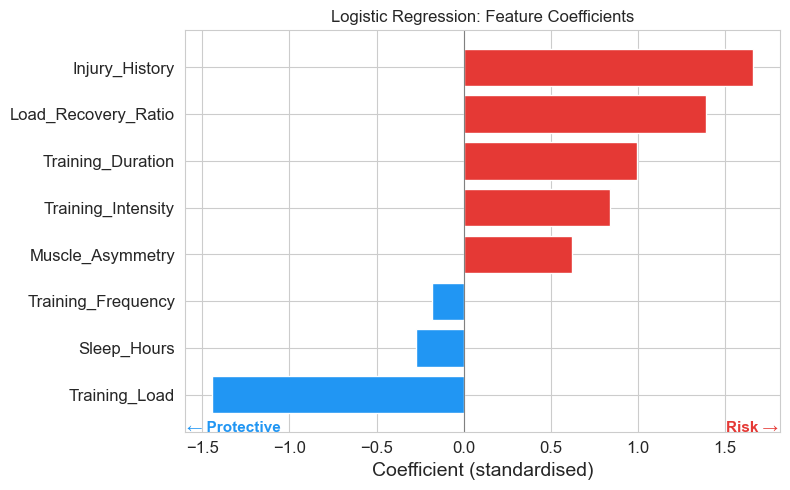

In [174]:
# Model coefficients: absolute importance and direction for each selected feature
coef_df = pd.DataFrame({
    'Feature':     selected_features,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient')

bar_colors = [COLOR_TARGET[1] if c > 0 else COLOR_TARGET[0] for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=bar_colors)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Coefficient (standardised)')
ax.set_title('Logistic Regression: Feature Coefficients')
ax.text(ax.get_xlim()[0] + 0.01, -0.8, '← Protective', color=COLOR_TARGET[0],
        fontsize=11, fontweight='bold')
ax.text(ax.get_xlim()[1] - 0.01, -0.8, 'Risk →', color=COLOR_TARGET[1],
        fontsize=11, fontweight='bold', ha='right')
plt.tight_layout()
plt.show()

**Coefficient plot interpretation:**

Five features push risk up (red bars) and three are protective (blue bars). `Injury_History` has the largest risk coefficient: each additional prior injury substantially increases the log-odds of future injury, holding all else constant. `Load_Recovery_Ratio` is the second largest risk driver, confirming that the stress-recovery imbalance is a primary linear signal. `Training_Duration`, `Training_Intensity` and `Muscle_Asymmetry` follow as further risk contributors.

**Limitation: `Training_Load` coefficient is not directly interpretable.** `Training_Load` is the product of `Training_Intensity` and `Training_Duration`, both of which are also present in the model. Logistic Regression is a linear equation, so `Training_Intensity` effectively appears three times: directly, inside `Load_Recovery_Ratio`, and inside `Training_Load`. The model still finds the correct predictions, but to do so it redistributes signal across the three related features in ways that can flip individual coefficient signs. The large negative coefficient on `Training_Load` does not mean high training load is protective — it is a mathematical artefact of the overlap. We retain all features because the model's predictive performance (AUC, recall) is unaffected. SHAP in Section 6 will provide a reliable view of each feature's true directional contribution, free from this collinearity artefact.

Test Set Performance: Logistic Regression

  Accuracy    : 0.7889
  Precision   : 0.6610
  Recall      : 0.6842
  F1          : 0.6724
  ROC-AUC     : 0.8270


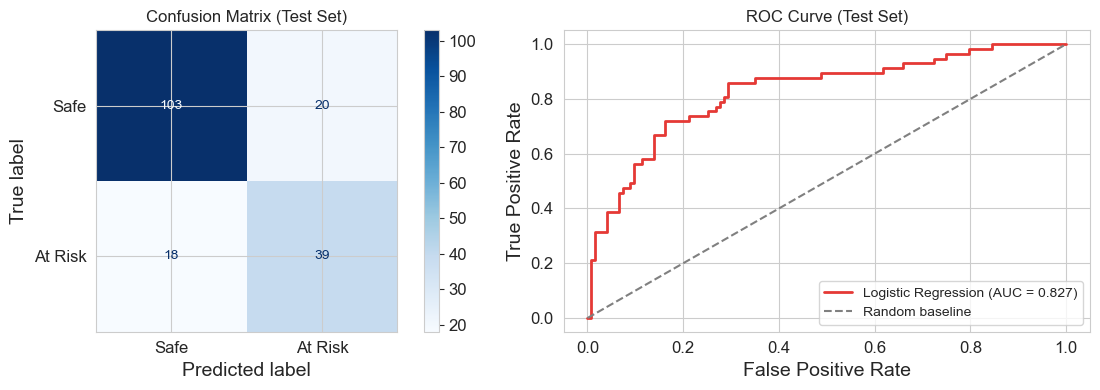

In [175]:
# Test set evaluation
lr_metrics = evaluate_model(log_reg, X_test_lr, y_test)
print("Test Set Performance: Logistic Regression\n")
for metric, value in lr_metrics.items():
    print(f"  {metric:<12}: {value:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_estimator(
    log_reg, X_test_lr, y_test,
    display_labels=['Safe', 'At Risk'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix (Test Set)')

# ROC curve
y_prob_lr = log_reg.predict_proba(X_test_lr)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
axes[1].plot(fpr, tpr, color=COLOR_TARGET[1], lw=2,
             label=f"Logistic Regression (AUC = {lr_metrics['ROC-AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], '--', color='grey', label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Test Set)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

**Confusion matrix:** Of the 57 at-risk athletes in the test set, the model correctly flags 39 (recall 68.4%) and misses 18 (false negatives). Of the 123 safe athletes, 103 are correctly cleared and 20 are unnecessarily flagged (false positives). The 18 missed at-risk athletes are the most costly errors from a business perspective: these are players cleared to train who carry undetected injury risk.

**ROC curve:** The curve rises steeply at low false positive rates, meaning the model can flag a substantial fraction of at-risk athletes while keeping false alarms low. This is the operating region of practical interest for coaching staff, who can act on a short high-confidence watchlist more easily than a long uncertain one.

**Logistic Regression: Summary**

This model was trained on the **8 features selected by RFE** (dropping the 6 weakest: `Recovery_Time`, `Flexibility_Score`, `BMI`, `Warmup_Time`, `Gender`, `Stress_Level`). 
| Metric | Value |
|---|---|
| Accuracy | 0.789 |
| Precision | 0.661 |
| Recall | 0.684 |
| F1 | 0.672 |
| ROC-AUC | **0.827** |

The t-SNE visualisation in Section 2.4 showed that safe and at-risk athletes are broadly intermingled, with no clean boundary separating them in feature space. A Logistic Regression can only draw a straight line through that space. Against that backdrop, an AUC of 0.827 is a strong result for a linear model: the class overlap explains the remaining errors, particularly the 18 missed at-risk athletes.

The recall of 68.4% leaves meaningful room for improvement. The remaining gap is most likely behind non-linear interactions: feature combinations that only matter jointly, not individually. Random Forest and XGBoost are designed to capture exactly these patterns. If they improve recall on the at-risk class without sacrificing too much precision, the added complexity is justified.